In [2]:
import os
import shutil

source_folder = r"C:\Users\User\Downloads\Stage PFA CRNS\web\uploads"
destination_folder = r"C:\Users\User\Downloads\Stage PFA CRNS\web\destination"

os.makedirs(destination_folder, exist_ok=True)

for filename in os.listdir(source_folder):
    source_file = os.path.join(source_folder, filename)
    dest_file = os.path.join(destination_folder, filename)

    if os.path.isfile(source_file):
        shutil.copy2(source_file, dest_file)

print("✅ Copy complete!")



✅ Copy complete!


In [29]:
!pip install opencv-python


In [2]:
import cv2
import numpy as np
import os

def apply_sma2_segmentation(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, segmented_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
    return segmented_image

def segment_folder(input_folder, output_folder):
    if not os.path.exists(input_folder):
        print(f"Input folder {input_folder} does not exist!")
        return

    os.makedirs(output_folder, exist_ok=True)
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

    count = 1
    for filename in sorted(os.listdir(input_folder)):
        if filename.lower().endswith(image_extensions):
            image_path = os.path.join(input_folder, filename)
            image = cv2.imread(image_path)

            if image is None:
                print(f"Impossible de charger l'image {image_path}")
                continue

            segmented_image = apply_sma2_segmentation(image)

            new_name = f"image{count}.png"
            save_path = os.path.join(output_folder, new_name)

            # Save using OpenCV instead of plt
            cv2.imwrite(save_path, segmented_image)

            print(f"Processed {filename} -> {new_name}")

            count += 1

if __name__ == "__main__":
    input_folder = r"C:\Users\User\Downloads\Stage PFA CRNS\web\uploads"
    output_folder = r"C:\Users\User\Downloads\Stage PFA CRNS\web\destination"
    segment_folder(input_folder, output_folder)


Processed 2.jpg -> image1.png
Processed 3.jpg -> image2.png
Processed WhatsApp_Image_2025-06-01_at_13.11.07_2.jpeg -> image3.png
Processed WhatsApp_Image_2025-06-01_at_13.11.07_3.jpeg -> image4.png
Processed image20.png -> image5.png


In [10]:
import os
import cv2
import numpy as np
from glob import glob

# === Input folders ===
dossier_images = r"C:\Users\User\Downloads\Stage PFA CRNS\web\destination"          # Folder with COLOR images
dossier_masks = r"C:\Users\User\Downloads\Stage PFA CRNS\web\destination_mask"     # Folder with GRAYSCALE masks (.png)

# === Output folders ===
dossier_sortie_images = r"C:\Users\User\Downloads\Stage PFA CRNS\web\morceau_images"
dossier_sortie_masks = r"C:\Users\User\Downloads\Stage PFA CRNS\web\morceau_mask"

os.makedirs(dossier_sortie_images, exist_ok=True)
os.makedirs(dossier_sortie_masks, exist_ok=True)

# === Load and sort images and masks ===
images = sorted(glob(os.path.join(dossier_images, "*")))            # Accept all formats
masks = sorted(glob(os.path.join(dossier_masks, "*.png")))          # Only PNG masks

# === Validate ===
if len(images) != len(masks):
    print(f"⚠️ ERROR: {len(images)} images ≠ {len(masks)} masks")
    exit()

# === Patch settings ===
patch_size = 256
overlap = 0.5
stride = int(patch_size * (1 - overlap))  # 128 for 50% overlap

total_patches = 0

# === Loop through paired image/mask ===
for pair_index, (img_path, mask_path) in enumerate(zip(images, masks)):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"⚠️ Could not read image or mask at index {pair_index}")
        continue

    h, w = img.shape[:2]
    index = 0

    for i in range(0, h, stride):
        for j in range(0, w, stride):
            # Extract patch from image and mask
            patch_img = img[i:i+patch_size, j:j+patch_size]
            patch_mask = mask[i:i+patch_size, j:j+patch_size]

            # Pad if smaller than patch size
            if patch_img.shape[0] != patch_size or patch_img.shape[1] != patch_size:
                pad_img = np.zeros((patch_size, patch_size, 3), dtype=np.uint8)
                pad_img[:patch_img.shape[0], :patch_img.shape[1]] = patch_img
                patch_img = pad_img

            if patch_mask.shape[0] != patch_size or patch_mask.shape[1] != patch_size:
                pad_mask = np.zeros((patch_size, patch_size), dtype=np.uint8)
                pad_mask[:patch_mask.shape[0], :patch_mask.shape[1]] = patch_mask
                patch_mask = pad_mask

            # Save both patches with same name
            filename = f"pair_{pair_index:03d}_part{index:03d}.png"
            cv2.imwrite(os.path.join(dossier_sortie_images, filename), patch_img)
            cv2.imwrite(os.path.join(dossier_sortie_masks, filename), patch_mask)

            index += 1
            total_patches += 1

    print(f"✔ {index} patches created for pair {pair_index}")

print(f"🧩 Total patches created: {total_patches}")




✔ 192 patches created for pair 0
✔ 414 patches created for pair 1
✔ 80 patches created for pair 2
✔ 80 patches created for pair 3
✔ 80 patches created for pair 4
🧩 Total patches created: 846


In [3]:
import os
import numpy as np
import cv2
import tensorflow as tf
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from tensorflow.keras import layers, models, utils
import matplotlib.pyplot as plt


In [3]:
dossier_images =r"C:\Users\User\Downloads\Stage PFA CRNS\web\mourceau"

taille_image =256
batch_size = 4
epochs = 2


In [4]:
transform = A.Compose([
    A.Resize(height=taille_image, width=taille_image),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
])


In [5]:
import os
import cv2
import numpy as np
from tensorflow.keras import utils  # assuming utils.Sequence

class DataGenerator(utils.Sequence):
    def __init__(self, dossier_images, dossier_masks, batch_size, taille_image, augmentation=True):
        self.dossier_images = dossier_images
        self.dossier_masks = dossier_masks
        self.image_filenames = sorted(os.listdir(dossier_images))  # assumes matching mask filenames
        self.batch_size = batch_size
        self.taille_image = taille_image
        self.augmentation = augmentation

    def __len__(self):
        return int(np.floor(len(self.image_filenames) / self.batch_size))

    def __getitem__(self, index):
        batch_filenames = self.image_filenames[index * self.batch_size:(index + 1) * self.batch_size]

        images, masks = [], []

        for filename in batch_filenames:
            img_path = os.path.join(self.dossier_images, filename)
            mask_path = os.path.join(self.dossier_masks, filename)

            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is None or mask is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.taille_image, self.taille_image))
            mask = cv2.resize(mask, (self.taille_image, self.taille_image))
            mask = (mask > 127).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)

            if self.augmentation:
                augmented = transform(image=img, mask=mask)
                img = augmented["image"]
                mask = augmented["mask"]

            img = img.astype(np.float32) / 255.0

            images.append(img)
            masks.append(mask)

        return np.array(images), np.array(masks)
train_generator = DataGenerator(
    dossier_images="C:/Users/User/Downloads/Stage PFA CRNS/web/morceau_images",
    dossier_masks="C:/Users/User/Downloads/Stage PFA CRNS/web/morceau_mask",
    batch_size=4,
    taille_image=256,
    augmentation=True
)


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

# === Convolutional block with optional dropout ===
def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    return x

# === Encoder block: conv block + max pooling ===
def encoder_block(x, filters, dropout_rate=0.0):
    f = conv_block(x, filters, dropout_rate)
    p = layers.MaxPooling2D((2, 2))(f)
    return f, p

# === Decoder block: transpose conv + skip connection + conv block ===
def decoder_block(x, skip, filters, dropout_rate=0.0):
    x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate)
    return x

# === Full U-Net model ===
def build_unet(input_shape=(256, 256, 3), dropout_rate=0.3):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64, dropout_rate)
    s2, p2 = encoder_block(p1, 128, dropout_rate)
    s3, p3 = encoder_block(p2, 256, dropout_rate)
    s4, p4 = encoder_block(p3, 512, dropout_rate)

    # Bridge (bottleneck)
    b1 = conv_block(p4, 1024, dropout_rate)

    # Decoder
    d1 = decoder_block(b1, s4, 512, dropout_rate)
    d2 = decoder_block(d1, s3, 256, dropout_rate)
    d3 = decoder_block(d2, s2, 128, dropout_rate)
    d4 = decoder_block(d3, s1, 64, dropout_rate)

    # Output: single-channel mask with sigmoid activation (binary)
    outputs = layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')(d4)

    model = models.Model(inputs, outputs)
    return model
taille_image = 256  # as you used earlier

model = build_unet(input_shape=(taille_image, taille_image, 3), dropout_rate=0.3)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.MeanIoU(num_classes=2)]
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 64)         1792      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 64)         256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 dropout (Dropout)           (None, 256, 256, 64)         0         ['batch_normalization[0][0

In [7]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.13.0
GPUs Available: []


In [8]:
"""model training """
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),#stops when there is no improvement
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)#go back to the best value found reduces the learning rate when performance plateaus
]

model.fit(train_generator, epochs=epochs, callbacks=callbacks)
model.save("C:/Users/User/Downloads/Stage PFA CRNS/web/model_saving/my_unet_model.h5")



Epoch 1/2
211/211 [==============================] - 1569s 7s/step - loss: 0.4131 - mean_io_u: 0.2528 - lr: 0.0010
Epoch 2/2
211/211 [==============================] - 1530s 7s/step - loss: 0.2929 - mean_io_u: 0.2548 - lr: 0.0010


C:\Users\User\anaconda3\envs\tf_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1/1 [==============================] - 1s 1s/step


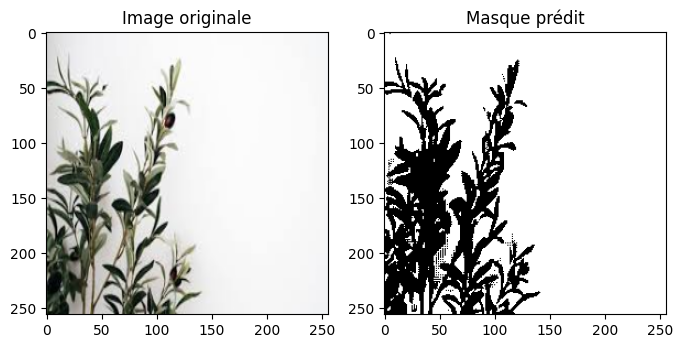

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model

# === Paramètres ===
image_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/images.jpg"
taille_image = 256

# === Charger le modèle ===
model = load_model("C:/Users/User/Downloads/Stage PFA CRNS/web/model_saving/my_unet_model.h5",
                   custom_objects={"MeanIoU": tf.keras.metrics.MeanIoU})

# === Charger et prétraiter l'image ===
image = cv2.imread(image_path)
image = cv2.resize(image, (taille_image, taille_image))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_norm = image_rgb / 255.0
image_input = np.expand_dims(image_norm, axis=0)  # shape: (1, 256, 256, 3)

# === Prédire ===
pred = model.predict(image_input)[0]  # shape: (256, 256, 1)
pred_mask = (pred > 0.5).astype(np.uint8)

# === Affichage ===
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Image originale")
plt.imshow(image_rgb)

plt.subplot(1, 2, 2)
plt.title("Masque prédit")
plt.imshow(pred_mask.squeeze(), cmap='gray')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


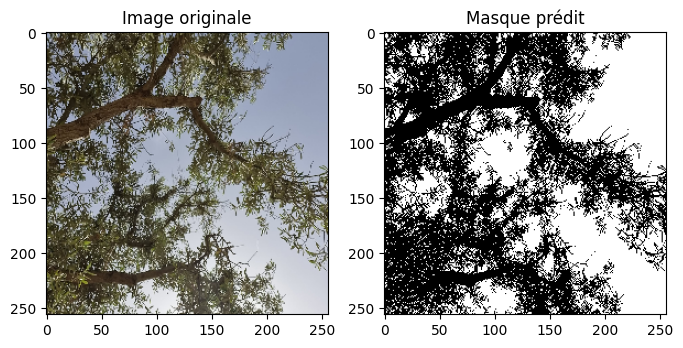

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model

# === Paramètres ===
image_path = "/content/drive/MyDrive/imagetest/oussema4.jpg"  # 🔁 Remplace avec ton image
taille_image = 256

# === Charger le modèle ===
model = load_model("/content/drive/MyDrive/oussemaunetttt_segmentation_qualite.h5",
                   custom_objects={"MeanIoU": tf.keras.metrics.MeanIoU})

# === Charger et prétraiter l'image ===
image = cv2.imread(image_path)
image = cv2.resize(image, (taille_image, taille_image))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_norm = image_rgb / 255.0
image_input = np.expand_dims(image_norm, axis=0)  # shape: (1, 256, 256, 3)

# === Prédire ===
pred = model.predict(image_input)[0]  # shape: (256, 256, 1)
pred_mask = (pred > 0.5).astype(np.uint8)

# === Affichage ===
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Image originale")
plt.imshow(image_rgb)

plt.subplot(1, 2, 2)
plt.title("Masque prédit")
plt.imshow(pred_mask.squeeze(), cmap='gray')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


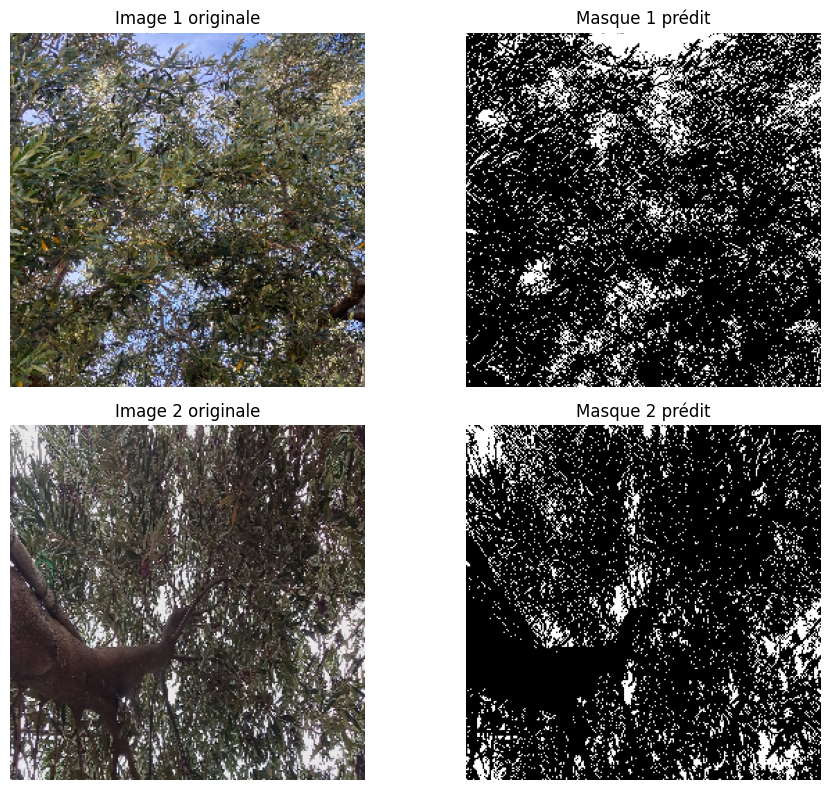

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model

# === Paramètres ===
image_path1 = "/content/drive/MyDrive/data1/new data/WhatsApp Image 2025-04-20 at 22.06.29.jpeg"
image_path2 = "/content/drive/MyDrive/imagetest/oussema7.jpg"  # ➕ Deuxième image
taille_image = 256

# === Charger le modèle ===
model = load_model("/content/drive/MyDrive/oussemaunetttt_segmentation_qualite.h5",
                   custom_objects={"MeanIoU": tf.keras.metrics.MeanIoU})

# === Fonction de traitement et prédiction ===
def predict_and_show(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (taille_image, taille_image))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_norm = image_rgb / 255.0
    image_input = np.expand_dims(image_norm, axis=0)

    pred = model.predict(image_input)[0]
    pred_mask = (pred > 0.5).astype(np.uint8)

    return image_rgb, pred_mask.squeeze()

# === Prédictions ===
image1_rgb, mask1 = predict_and_show(image_path1)
image2_rgb, mask2 = predict_and_show(image_path2)

# === Affichage ===
plt.figure(figsize=(10, 8))

# Image 1
plt.subplot(2, 2, 1)
plt.title("Image 1 originale")
plt.imshow(image1_rgb)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Masque 1 prédit")
plt.imshow(mask1, cmap='gray')
plt.axis('off')

# Image 2
plt.subplot(2, 2, 3)
plt.title("Image 2 originale")
plt.imshow(image2_rgb)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Masque 2 prédit")
plt.imshow(mask2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
/content/drive/MyDrive/imagetest/oussema4.jpg

In [5]:
import os
import random
import numpy as np
import tensorflow as tf
import cv2
from sklearn.metrics import accuracy_score, recall_score
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import load_model


# 🔧 Paramètres
taille_image = 256
sample_size = 5  # Nombre d'images pour l'échantillon
dossier_images = "C:/Users/User/Downloads/Stage PFA CRNS/web/uploads"

# 📦 Charger le modèle
model = load_model("C:/Users/User/Downloads/Stage PFA CRNS/web/model_saving/my_unet_model.h5",
                   custom_objects={"MeanIoU": tf.keras.metrics.MeanIoU})

# 📂 Obtenir une liste d'images valides
image_paths = [os.path.join(dossier_images, f) for f in os.listdir(dossier_images)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_paths = random.sample(image_paths, min(sample_size, len(image_paths)))

y_true_all = []
y_pred_all = []

# 🔍 Parcourir les images et évaluer
for img_path in image_paths:
    # Charger image et masque (supposé être dans la même image pour ton cas)
    img = cv2.imread(img_path)
    mask = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    # Prétraitement
    img = cv2.resize(img, (taille_image, taille_image), interpolation=cv2.INTER_CUBIC)
    mask = cv2.resize(mask, (taille_image, taille_image), interpolation=cv2.INTER_NEAREST)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    mask = (mask > 127).astype(np.uint8)  # Binariser le masque
    mask = np.expand_dims(mask, axis=-1)  # [H, W] -> [H, W, 1]

    img = preprocess_input(img)
    img_input = np.expand_dims(img, axis=0)  # [H, W, C] -> [1, H, W, C]

    # Prédiction
    pred = model.predict(img_input)[0]
    pred_bin = (pred > 0.8).astype(np.uint8)

    y_true_all.extend(mask.flatten())
    y_pred_all.extend(pred_bin.flatten())

# 📊 Métriques
accuracy = accuracy_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)

print(f"✅ Accuracy (sur {len(image_paths)} images) : {accuracy:.4f}")
print(f"✅ Recall   (sur {len(image_paths)} images) : {recall:.4f}")


1/1 [==============================] - 0s 281ms/step
✅ Accuracy (sur 5 images) : 0.7200
✅ Recall   (sur 5 images) : 0.8723


In [6]:
from sklearn.metrics import precision_score, f1_score

precision = precision_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)

print(f"✅ Precision : {precision:.4f}")
print(f"✅ F1-score  : {f1:.4f}")

✅ Precision : 0.6753
✅ F1-score  : 0.7612


1/1 [==============================] - 1s 1s/step


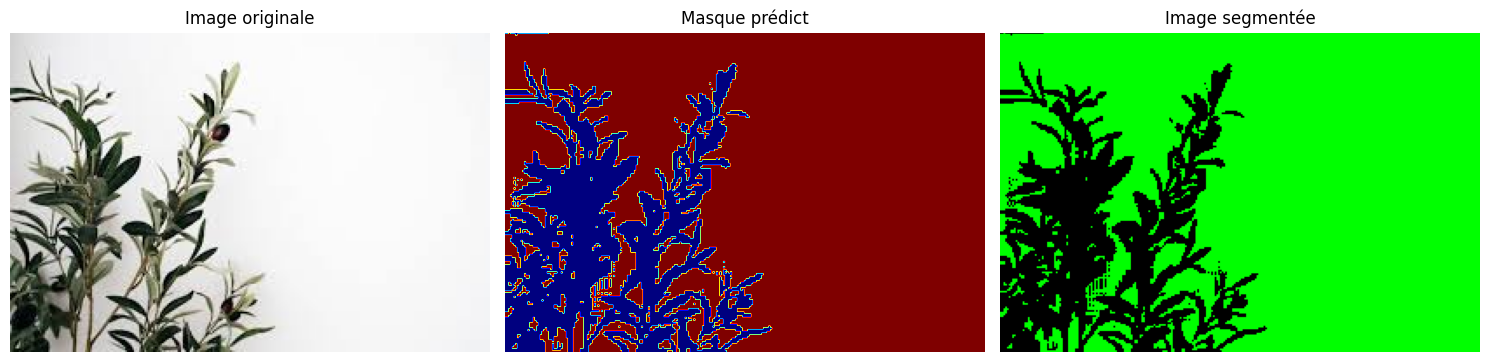

✅ Image segmentée enregistrée en HD à : C:/Users/User/Downloads/Stage PFA CRNS/collab/image.jpg


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model

# === Paramètres ===
image_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/images.jpg"
taille_modele = 256  # uniquement pour le modèle

# === Charger le modèle ===
model = load_model("C:/Users/User/Downloads/Stage PFA CRNS/web/model_saving/my_unet_model.h5",
                   custom_objects={"MeanIoU": tf.keras.metrics.MeanIoU})

# === Charger l'image originale en taille réelle ===
image_orig = cv2.imread(image_path)
image_rgb_orig = cv2.cvtColor(image_orig, cv2.COLOR_BGR2RGB)

# === Redimensionner une copie pour l'entrée du modèle ===
image_small = cv2.resize(image_rgb_orig, (taille_modele, taille_modele))
image_norm = image_small / 255.0
image_input = np.expand_dims(image_norm, axis=0)

# === Prédiction ===
pred = model.predict(image_input)[0]
if pred.shape[-1] > 1:
    pred_mask = np.argmax(pred, axis=-1)  # (256, 256)
else:
    pred_mask = (pred > 0.5).astype(np.uint8).squeeze()

# === Redimensionner le masque à la taille originale ===
mask_resized = cv2.resize(pred_mask.astype(np.uint8), (image_rgb_orig.shape[1], image_rgb_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

# === Définir les couleurs pour chaque classe ===
colors = {
    0: [0, 0, 0],       # Fond
    1: [0, 255, 0],     # Classe 1 : vert
    2: [255, 0, 0],     # Classe 2 : rouge
}

# === Créer l'image segmentée en grand format ===
segmented_image = np.zeros_like(image_rgb_orig)
for class_id, color in colors.items():
    segmented_image[mask_resized == class_id] = color

# === Affichage ===
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Image originale")
plt.imshow(image_rgb_orig)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Masque prédict")
plt.imshow(mask_resized, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Image segmentée")
plt.imshow(segmented_image)
plt.axis('off')

plt.tight_layout()
plt.show()

# === Sauvegarde en HD ===
save_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/image.jpg"
cv2.imwrite(save_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))
print(f"✅ Image segmentée enregistrée en HD à : {save_path}")
